# 01 - Data Ingestion (Day 1)

This notebook demonstrates loading the raw CSV files for the Bluestock Mutual Fund Capstone project.

In [1]:
import pandas as pd
import os
from pathlib import Path

data_dir = Path('../datasets')
files = sorted(data_dir.glob('*.csv'))
print(f'Found {len(files)} CSV files.')

Found 10 CSV files.


In [2]:
# Load and inspect first dataset
fund_master = pd.read_csv(data_dir / '01_fund_master.csv')
display(fund_master.head())

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


## Dataset Overview & Visualizations

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load all datasets
datasets = {}
for file in files:
    datasets[file.stem.split('_', 1)[1]] = pd.read_csv(file)

print("📊 DATASET INVENTORY:")
for name, df in datasets.items():
    print(f"  ✓ {name:30s} | Shape: {str(df.shape):15s} | Size: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


📊 DATASET INVENTORY:
  ✓ fund_master                    | Shape: (40, 15)        | Size: 9.9 KB
  ✓ nav_history                    | Shape: (46000, 3)      | Size: 1527.5 KB
  ✓ aum_by_fund_house              | Shape: (90, 5)         | Size: 6.0 KB
  ✓ monthly_sip_inflows            | Shape: (48, 6)         | Size: 2.7 KB
  ✓ category_inflows               | Shape: (144, 3)        | Size: 5.8 KB
  ✓ industry_folio_count           | Shape: (21, 6)         | Size: 1.3 KB
  ✓ scheme_performance             | Shape: (40, 19)        | Size: 9.2 KB
  ✓ investor_transactions          | Shape: (32778, 13)     | Size: 5500.5 KB
  ✓ portfolio_holdings             | Shape: (322, 8)        | Size: 33.6 KB
  ✓ benchmark_indices              | Shape: (8050, 3)       | Size: 350.5 KB


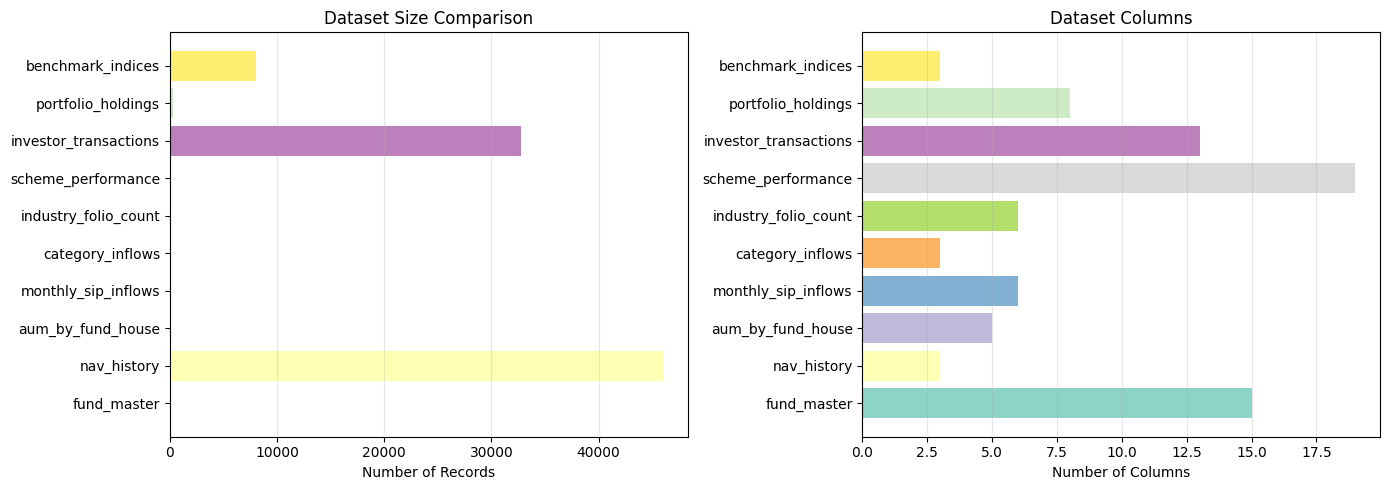

✅ Dataset overview visualized


In [4]:
# Visualize dataset sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dataset size comparison
names = list(datasets.keys())
sizes = [datasets[n].shape[0] for n in names]
colors = plt.cm.Set3(np.linspace(0, 1, len(names)))

axes[0].barh(names, sizes, color=colors)
axes[0].set_xlabel('Number of Records')
axes[0].set_title('Dataset Size Comparison')
axes[0].grid(axis='x', alpha=0.3)

# Dataset columns
col_counts = [datasets[n].shape[1] for n in names]
axes[1].barh(names, col_counts, color=colors)
axes[1].set_xlabel('Number of Columns')
axes[1].set_title('Dataset Columns')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Dataset overview visualized")

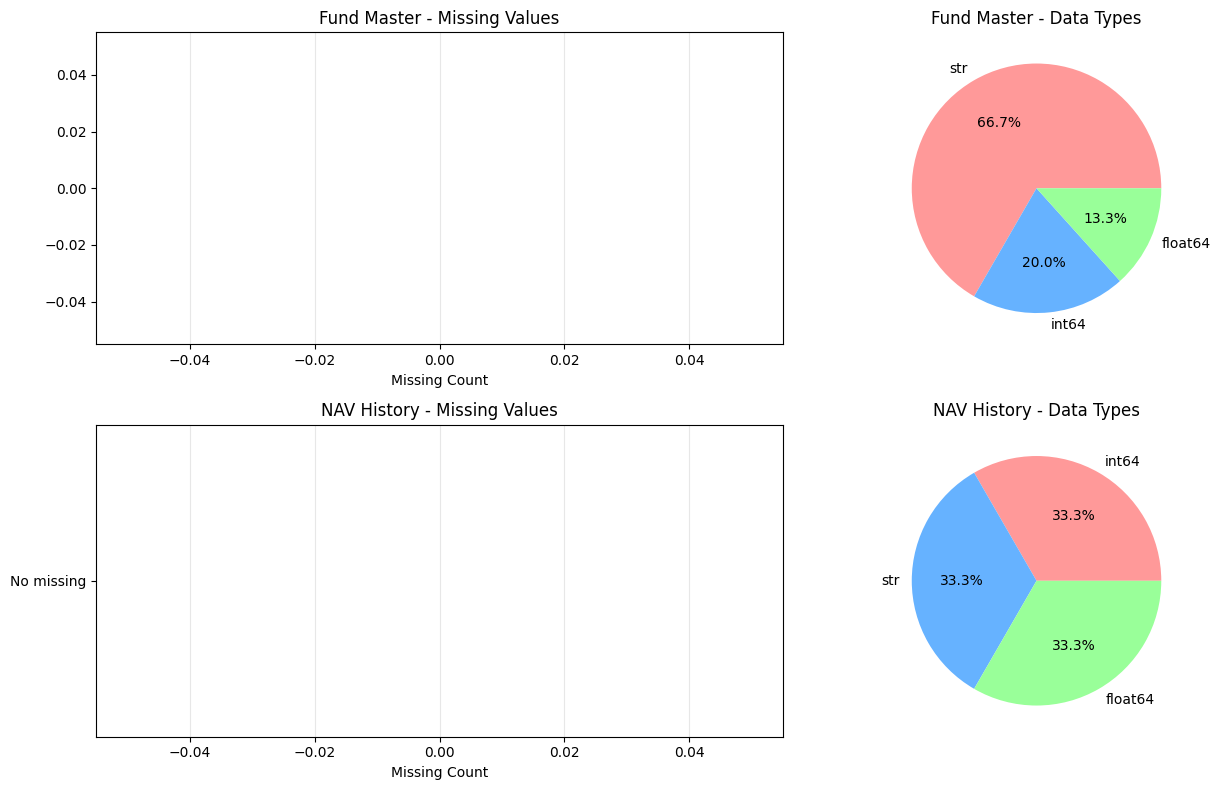

✅ Data quality visualized


In [5]:
# Missing values heatmap for Fund Master
fund_master = datasets['fund_master']
nav_history = datasets['nav_history']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Fund Master missing values
missing_fm = fund_master.isnull().sum()
axes[0, 0].barh(missing_fm[missing_fm > 0].index, missing_fm[missing_fm > 0].values, color='coral')
axes[0, 0].set_xlabel('Missing Count')
axes[0, 0].set_title('Fund Master - Missing Values')
axes[0, 0].grid(axis='x', alpha=0.3)

# Data types distribution
type_counts = fund_master.dtypes.value_counts()
axes[0, 1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=['#FF9999', '#66B2FF', '#99FF99'])
axes[0, 1].set_title('Fund Master - Data Types')

# NAV history missing values
missing_nav = nav_history.isnull().sum()
axes[1, 0].barh(missing_nav[missing_nav > 0].index if len(missing_nav[missing_nav > 0]) > 0 else ['No missing'], missing_nav[missing_nav > 0].values if len(missing_nav[missing_nav > 0]) > 0 else [0], color='lightblue')
axes[1, 0].set_xlabel('Missing Count')
axes[1, 0].set_title('NAV History - Missing Values')
axes[1, 0].grid(axis='x', alpha=0.3)

# NAV data types
type_counts_nav = nav_history.dtypes.value_counts()
axes[1, 1].pie(type_counts_nav.values, labels=type_counts_nav.index, autopct='%1.1f%%', colors=['#FF9999', '#66B2FF', '#99FF99'])
axes[1, 1].set_title('NAV History - Data Types')

plt.tight_layout()
plt.show()

print("✅ Data quality visualized")